**NumPy Basics**

Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Final_Score as NumPy array

In [ ]:
df = pd.read_csv("/content/sample_data/student_performance.csv")

final_scores = np.array(df["Final_Score"])
print(final_scores)

[52 57 60 64 68 71 74 77 79 83 63 70 75 56 69 73 80 58 72 78]


Compute Mean, Median, Standard Deviation

In [ ]:
mean_score = np.mean(final_scores)
median_score = np.median(final_scores)
std_score = np.std(final_scores)

print("Mean:", mean_score)
print("Median:", median_score)
print("Standard Deviation:", std_score)

Mean: 68.95
Median: 70.5
Standard Deviation: 8.71478628538876


Min–Max Normalization



In [ ]:
min_score = np.min(final_scores)
max_score = np.max(final_scores)

normalized_scores = (final_scores - min_score) / (max_score - min_score)
print(normalized_scores)

[0.         0.16129032 0.25806452 0.38709677 0.51612903 0.61290323
 0.70967742 0.80645161 0.87096774 1.         0.35483871 0.58064516
 0.74193548 0.12903226 0.5483871  0.67741935 0.90322581 0.19354839
 0.64516129 0.83870968]


**Pandas Data Handling**

Load CSV file using Pandas

In [ ]:
df = pd.read_csv("/content/sample_data/student_performance.csv")
df.head()

,Hours_Studied,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,1,60,55,50,52
1,2,65,58,55,57
2,3,70,60,58,60
3,4,75,65,62,64
4,5,80,68,65,68


Check shape, columns, and missing values

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (20, 5)
Columns: Index(['Hours_Studied', 'Attendance', 'Assignment_Score', 'Midterm_Score',
       'Final_Score'],
      dtype='object')

Missing Values:
Hours_Studied       0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


Create Performance Label based on Final_Score

In [ ]:
df["Performance"] = df["Final_Score"].apply(
    lambda x: "Pass" if x >= 60 else "Fail"
)

df.head()

,Hours_Studied,Attendance,Assignment_Score,Midterm_Score,Final_Score,Performance
0,1,60,55,50,52,Fail
1,2,65,58,55,57,Fail
2,3,70,60,58,60,Pass
3,4,75,65,62,64,Pass
4,5,80,68,65,68,Pass


**Matplotlib Visualization**

Line Plot: Hours_Studied vs Final_Score

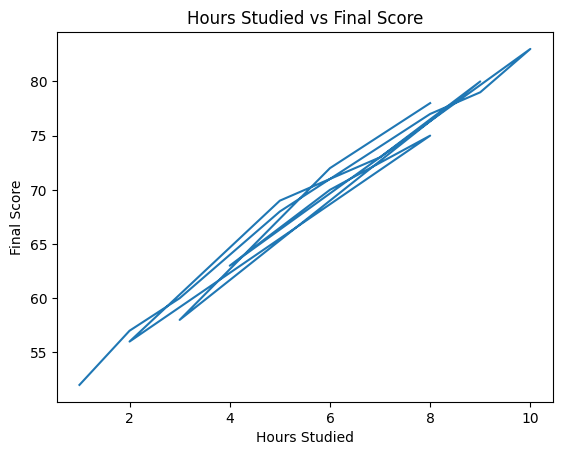

In [ ]:
plt.figure()
plt.plot(df["Hours_Studied"], df["Final_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.title("Hours Studied vs Final Score")
plt.show()

Histogram of Final_Score

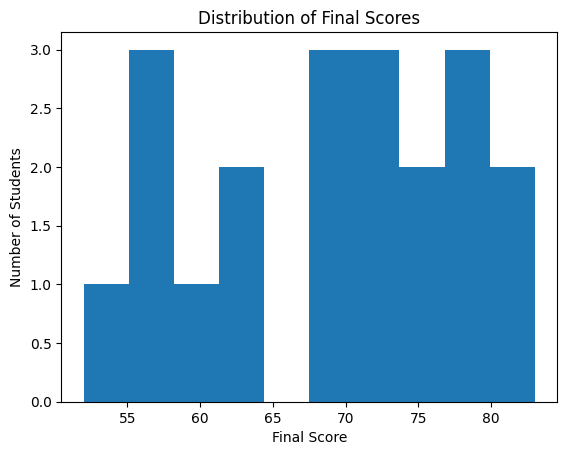

In [ ]:
plt.figure()
plt.hist(df["Final_Score"])
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Scores")
plt.show()

**Seaborn Visualization**

Scatter Plot using Seaborn

Text(0.5, 1.0, 'Hours Studied vs Final Score')

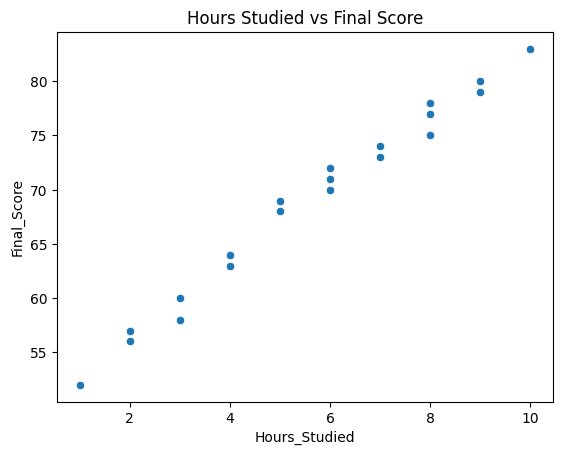

In [ ]:
sns.scatterplot(
    x="Hours_Studied",
    y="Final_Score",
    data=df
)
plt.title("Hours Studied vs Final Score")

Heatmap for Correlation Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

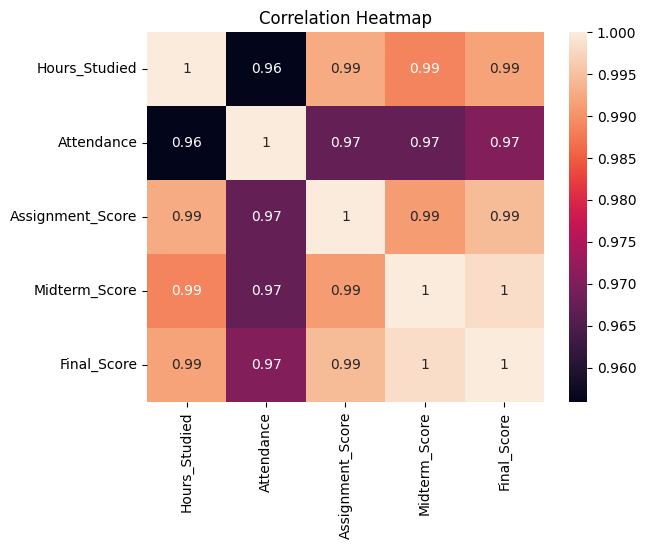

In [ ]:
corr = df.drop(columns=["Performance"]).corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")

Boxplot for Categorical Analysis

Text(0.5, 1.0, 'Performance vs Final Score')

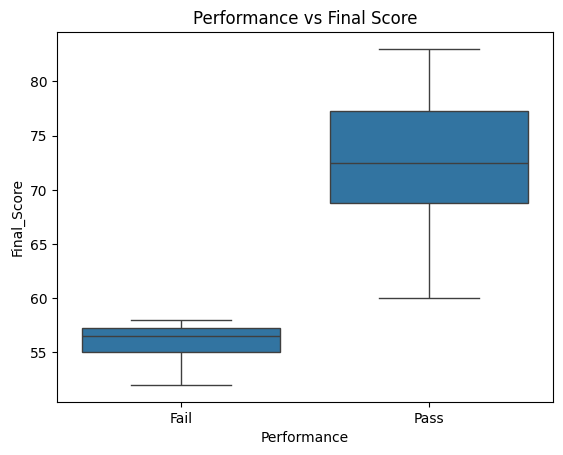

In [ ]:
sns.boxplot(
    x="Performance",
    y="Final_Score",
    data=df
)
plt.title("Performance vs Final Score")

# Experiment - 1

   Hours_Studied  Attendance  Assignment_Score  Midterm_Score  Final_Score
0              1          60                55             50           52
1              2          65                58             55           57
2              3          70                60             58           60
3              4          75                65             62           64
4              5          80                68             65           68

===== LINEAR REGRESSION RESULTS =====
MAE: 0.41749050153075906
MSE: 0.2612765457256682
RMSE: 0.5111521747245806
R2 Score: 0.9957516008825095


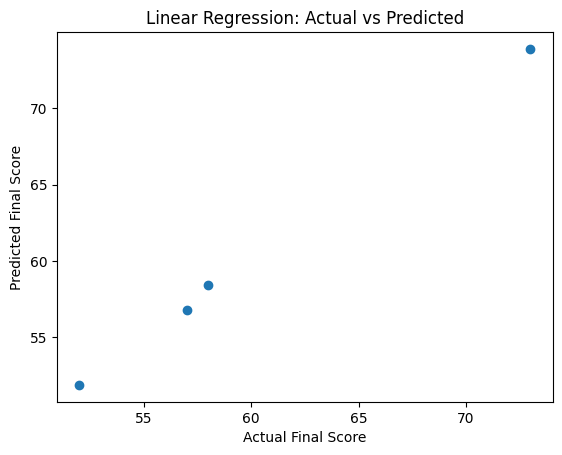


Pass/Fail Distribution:
Pass
1    13
0     7
Name: count, dtype: int64

===== LOGISTIC REGRESSION RESULTS =====
Accuracy: 1.0
Confusion Matrix:
 [[3 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



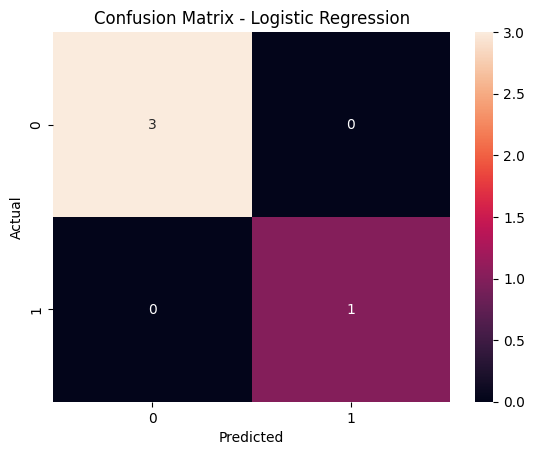

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



===== HYPERPARAMETER TUNING =====
Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 1.0


In [ ]:
# =====================================
# STEP 1: Import Required Libraries
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report
)

# =====================================
# STEP 2: Load Dataset
# (Make sure file is in sample_data)
# =====================================
df = pd.read_csv("/content/sample_data/student_performance.csv")
print(df.head())

# =====================================
# STEP 3: Data Cleaning
# =====================================
df = df.dropna()

# =====================================
# PART A: LINEAR REGRESSION
# Target: Final_Score (Continuous)
# =====================================

X = df.drop(columns=["Final_Score"])
y = df["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n===== LINEAR REGRESSION RESULTS =====")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# =====================================
# PART B: LOGISTIC REGRESSION
# Convert Final_Score → Pass / Fail
# Threshold = 65 (IMPORTANT)
# =====================================

df["Pass"] = df["Final_Score"].apply(lambda x: 1 if x >= 65 else 0)

# Check both classes exist
print("\nPass/Fail Distribution:")
print(df["Pass"].value_counts())

X = df.drop(columns=["Final_Score", "Pass"])
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# =====================================
# PART C: HYPERPARAMETER TUNING
# Logistic Regression
# =====================================

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("\n===== HYPERPARAMETER TUNING =====")
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

# Experiment - 2

Dataset Preview:
    Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Squa

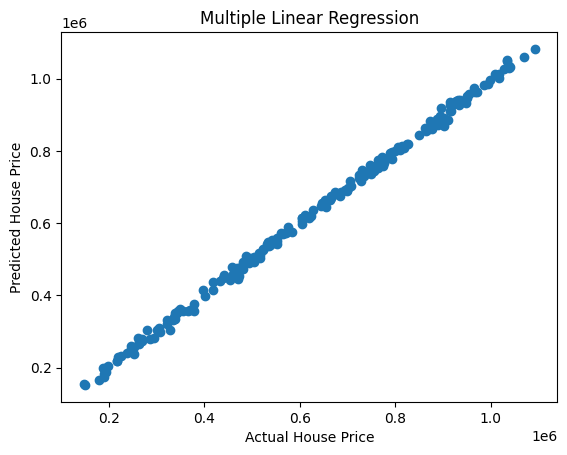


===== RIDGE REGRESSION =====
MAE: 8241.898358133865
MSE: 102486578.62155962
RMSE: 10123.565509323265
R2 Score: 0.998410046605628


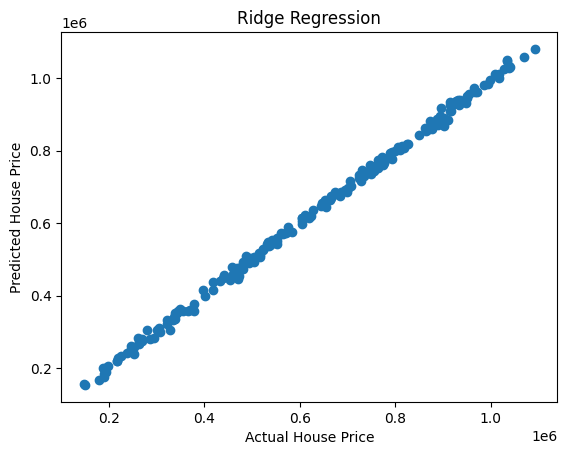


===== LASSO REGRESSION =====
MAE: 8174.585809784338
MSE: 101434824.93285091
RMSE: 10071.48573611912
R2 Score: 0.9984263632723556


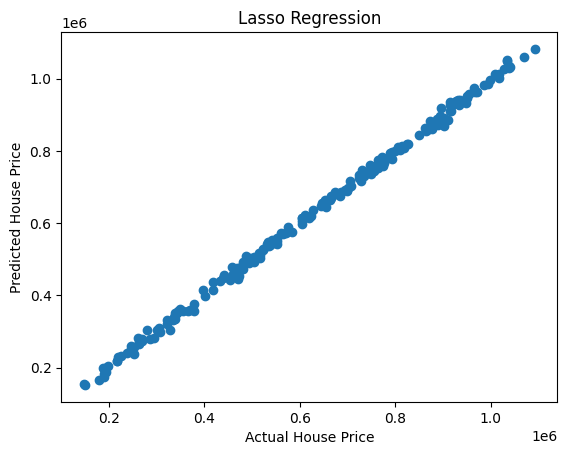

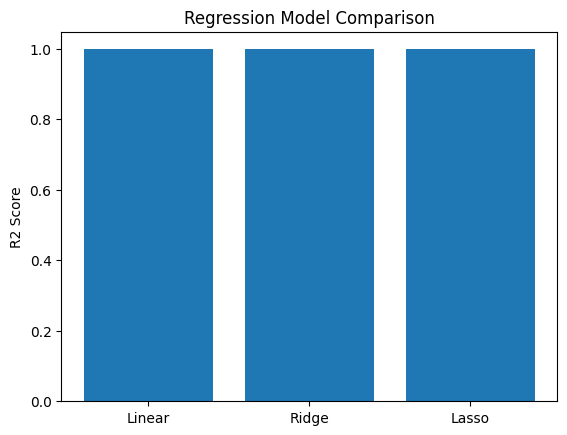


===== HYPERPARAMETER TUNING RESULTS =====
Best Ridge Alpha: {'alpha': 0.001}
Best Lasso Alpha: {'alpha': 10}


In [ ]:
# =====================================
# IMPORT LIBRARIES
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =====================================
# LOAD DATASET
# =====================================
# Upload home_value_insights.csv before running

df = pd.read_csv("/content/sample_data/house_price_regression_dataset.csv")
print("Dataset Preview:\n", df.head())


# =====================================
# DATA CHECK & CLEANING
# =====================================
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()


# =====================================
# FEATURE & TARGET SPLIT
# =====================================
X = df.drop(columns=["House_Price"])
y = df["House_Price"]


# =====================================
# FEATURE SCALING
# =====================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =====================================
# TRAIN-TEST SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# =====================================
# MULTIPLE LINEAR REGRESSION
# =====================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n===== MULTIPLE LINEAR REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Multiple Linear Regression")
plt.show()


# =====================================
# RIDGE REGRESSION
# =====================================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("\n===== RIDGE REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Ridge Regression")
plt.show()


# =====================================
# LASSO REGRESSION
# =====================================
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("\n===== LASSO REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

plt.figure()
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Lasso Regression")
plt.show()


# =====================================
# MODEL COMPARISON GRAPH
# =====================================
models = ["Linear", "Ridge", "Lasso"]
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.figure()
plt.bar(models, r2_scores)
plt.ylabel("R2 Score")
plt.title("Regression Model Comparison")
plt.show()


# =====================================
# HYPERPARAMETER TUNING
# =====================================
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5)
ridge_grid.fit(X_train, y_train)

lasso_grid = GridSearchCV(Lasso(), param_grid, cv=5)
lasso_grid.fit(X_train, y_train)

print("\n===== HYPERPARAMETER TUNING RESULTS =====")
print("Best Ridge Alpha:", ridge_grid.best_params_)
print("Best Lasso Alpha:", lasso_grid.best_params_)

# Experiment - 3

In [ ]:
/content/sample_data/Titanic-Dataset.csv